In [59]:
#%pip install pooch 
%pip install scikit-image

# Core scverse libraries 
from __future__ import annotations

import anndata as ad

import scikitimage

# Data retrieval
import pooch
import scanpy as sc
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.


ModuleNotFoundError: No module named 'scikitimage'

In [73]:
sc.settings.set_figure_params(dpi=150, facecolor="white")

In [25]:
EXAMPLE_DATA = pooch.create(
    path=pooch.os_cache("scverse_tutorials"),
    base_url="doi:10.6084/m9.figshare.22716739.v1/",
)

EXAMPLE_DATA.load_registry_from_doi()

In [27]:
samples = {
    "s1d1": "s1d1_filtered_feature_bc_matrix.h5",
    "s1d3": "s1d3_filtered_feature_bc_matrix.h5",
}
adatas = {}

for sample_id, filename in samples.items():
    path = EXAMPLE_DATA.fetch(filename)
    sample_adata = sc.read_10x_h5(path)
    sample_adata.var_names_make_unique()
    adatas[sample_id] = sample_adata

adata = ad.concat(adatas, label="sample")
adata.obs_names_make_unique()
print(adata.obs["sample"].value_counts())
adata

/usr/local/Caskroom/miniconda/base/envs/scanpy-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/Caskroom/miniconda/base/envs/scanpy-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


sample
s1d1    8785
s1d3    8340
Name: count, dtype: int64


/usr/local/Caskroom/miniconda/base/envs/scanpy-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/Caskroom/miniconda/base/envs/scanpy-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1884: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/Caskroom/miniconda/base/envs/scanpy-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1882: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 17125 × 36601
    obs: 'sample'

In [30]:
# Quality Control

# Check mitochondrial gene percentage 

# MT- human    Mt- mouse 
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# Ribosome genes
adata.var["ribo"] = adata.var_names.str.startswith("RPS", "RPL")
# Hemogolbin genes 
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")


/var/folders/tb/x4yh6yqj0b1fs7v36p_b0j3c0000gn/T/ipykernel_76426/3531767506.py:8: FutureWarning: Allowing a non-bool 'na' in obj.str.startswith is deprecated and will raise in a future version.
  adata.var["ribo"] = adata.var_names.str.startswith("RPS", "RPL")


In [33]:
# Calculate the gene percentages of the above 
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace="True", log1p = "True")

In [40]:
adata.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb
AAACCCAAGGATGGCT-1,s1d1,2103,7.651596,8663.0,9.066932,42.721921,59.667552,69.744892,79.348955,460.0,6.133398,5.309938,1458.0,7.285507,16.830196,17.0,2.890372,0.196237
AAACCCAAGGCCTAGA-1,s1d1,3916,8.273081,12853.0,9.461411,35.843772,44.262040,52.376877,62.763557,1790.0,7.490530,13.926710,684.0,6.529419,5.321715,58.0,4.077538,0.451257
AAACCCAAGTGAGTGC-1,s1d1,683,6.527958,1631.0,7.397562,56.284488,62.599632,70.386266,88.779890,581.0,6.366470,35.622318,23.0,3.178054,1.410178,13.0,2.639057,0.797057
AAACCCACAAGAGGCT-1,s1d1,4330,8.373554,17345.0,9.761117,27.662150,38.420294,48.901701,62.023638,780.0,6.660575,4.496973,1678.0,7.425954,9.674258,44.0,3.806663,0.253675
AAACCCACATCGTGGC-1,s1d1,325,5.786897,555.0,6.320768,49.909910,59.459459,77.477477,100.000000,159.0,5.075174,28.648647,8.0,2.197225,1.441442,26.0,3.295837,4.684685
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGAGAGTCTGG-1,s1d3,277,5.627621,615.0,6.423247,63.089431,71.219512,87.479675,100.000000,282.0,5.645447,45.853661,13.0,2.639057,2.113821,20.0,3.044523,3.252032
TTTGTTGCAGACAATA-1,s1d3,3797,8.242230,13218.0,9.489410,30.753518,44.628537,53.691935,64.684521,864.0,6.762730,6.536541,1683.0,7.428927,12.732637,42.0,3.761200,0.317749
TTTGTTGCATGTTACG-1,s1d3,3089,8.035926,27280.0,10.213945,64.409824,71.671554,78.317449,85.054985,1025.0,6.933423,3.757332,1554.0,7.349231,5.696481,13145.0,9.483872,48.185482
TTTGTTGGTAGTCACT-1,s1d3,379,5.940171,698.0,6.549651,52.865330,60.028653,74.355301,100.000000,143.0,4.969813,20.487106,28.0,3.367296,4.011461,39.0,3.688879,5.587393


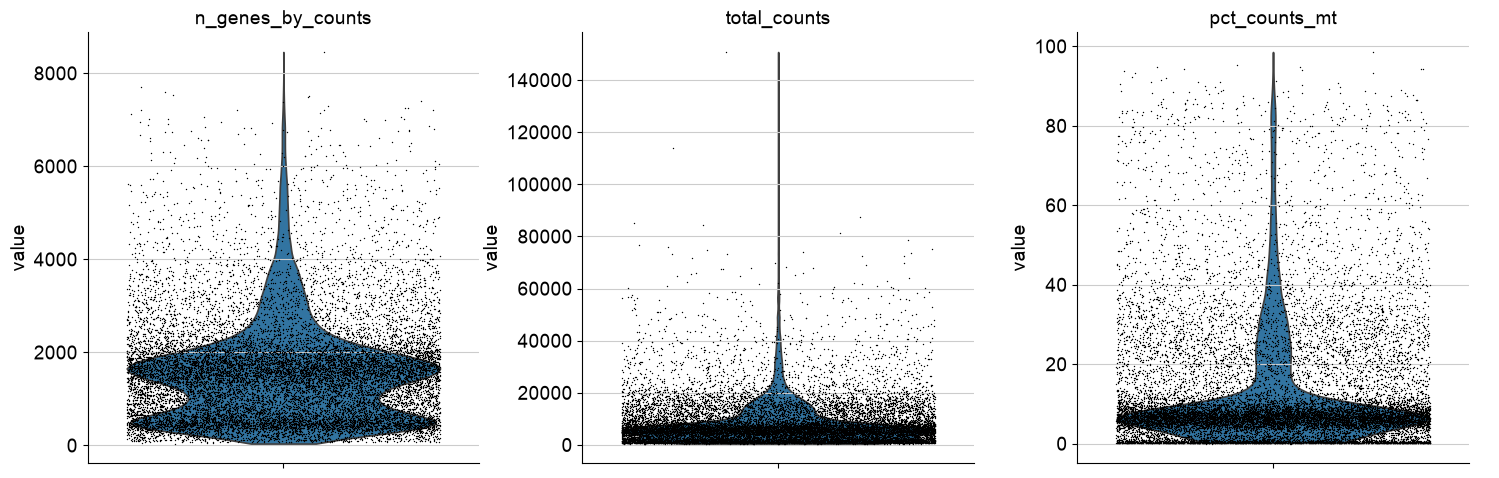

In [41]:
# Check violin plots for gene percentags 
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"], jitter = 0.4, multi_panel = "True")

<Figure size 40000x40000 with 0 Axes>

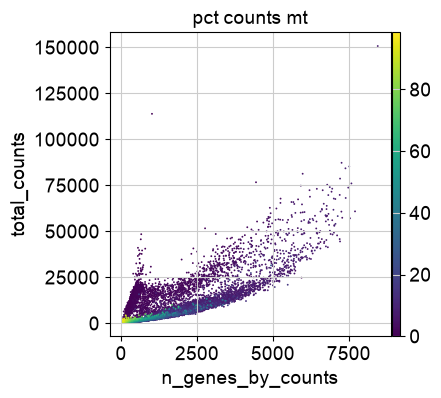

In [47]:
# Continue QC with Scatter plots for the gene counts 
sc.pl.scatter(adata, "n_genes_by_counts", "total_counts", color = "pct_counts_mt")

In [61]:
# Filter out the genes with high mt/ gene counts 
sc.pp.filter_cells(adata, min_genes = 100)
sc.pp.filter_genes(adata, min_cells = 3)

In [62]:
# Doublet Detection 
sc.pp.scrublet(adata, batch_key = "sample")

In [63]:
# Saving the count data 
adata.layers["counts"] = adata.X.copy()

In [64]:
# Normalize to median total counts 
sc.pp.normalize_total(adata)

#Logamarize the data 
sc.pp.log1p(adata)

In [65]:
# Get the highly variable genes 
sc.pp.highly_variable_genes(adata, n_top_genes = 2000, batch_key = "sample")

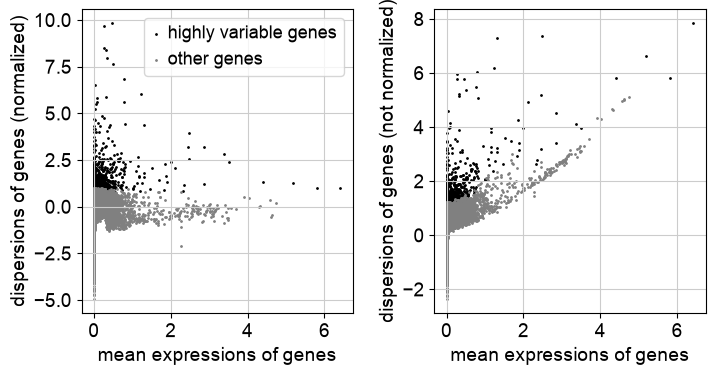

In [66]:
# Plot the highly variable genes
sc.pl.highly_variable_genes(adata)

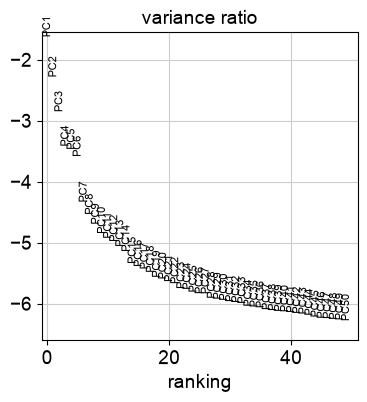

In [68]:
# Reduce dimensionality with pca plot
sc.tl.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs = 50, log = True)

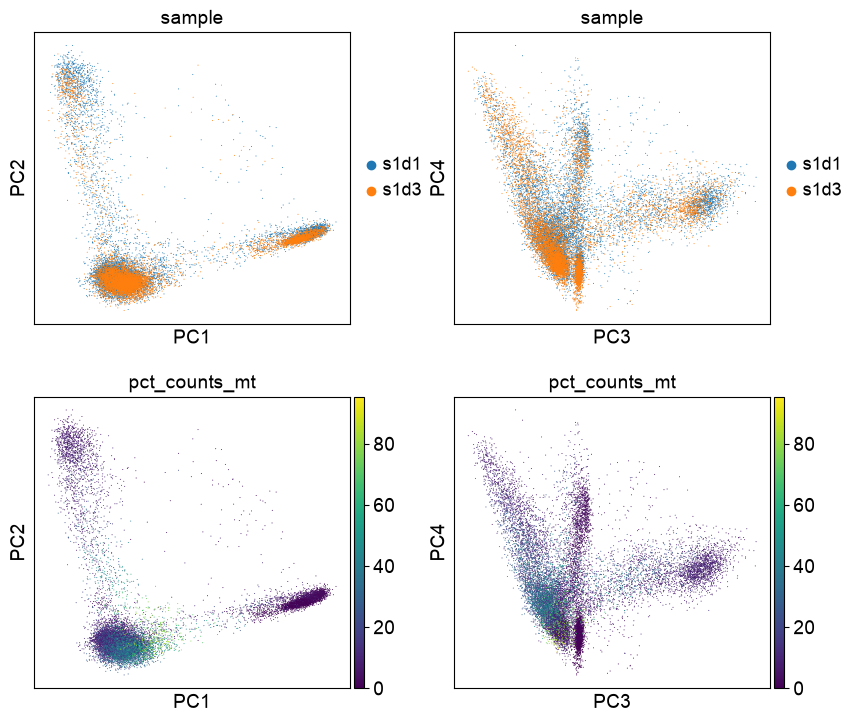

In [69]:
# Plot the pca's to check for batch effects 
sc.pl.pca(
    adata, 
    color = ["sample", "sample", "pct_counts_mt", "pct_counts_mt"],
    dimensions = [(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols = 2, 
    size = 2)

In [70]:
# Get the nearest neighbors 
sc.pp.neighbors(adata)

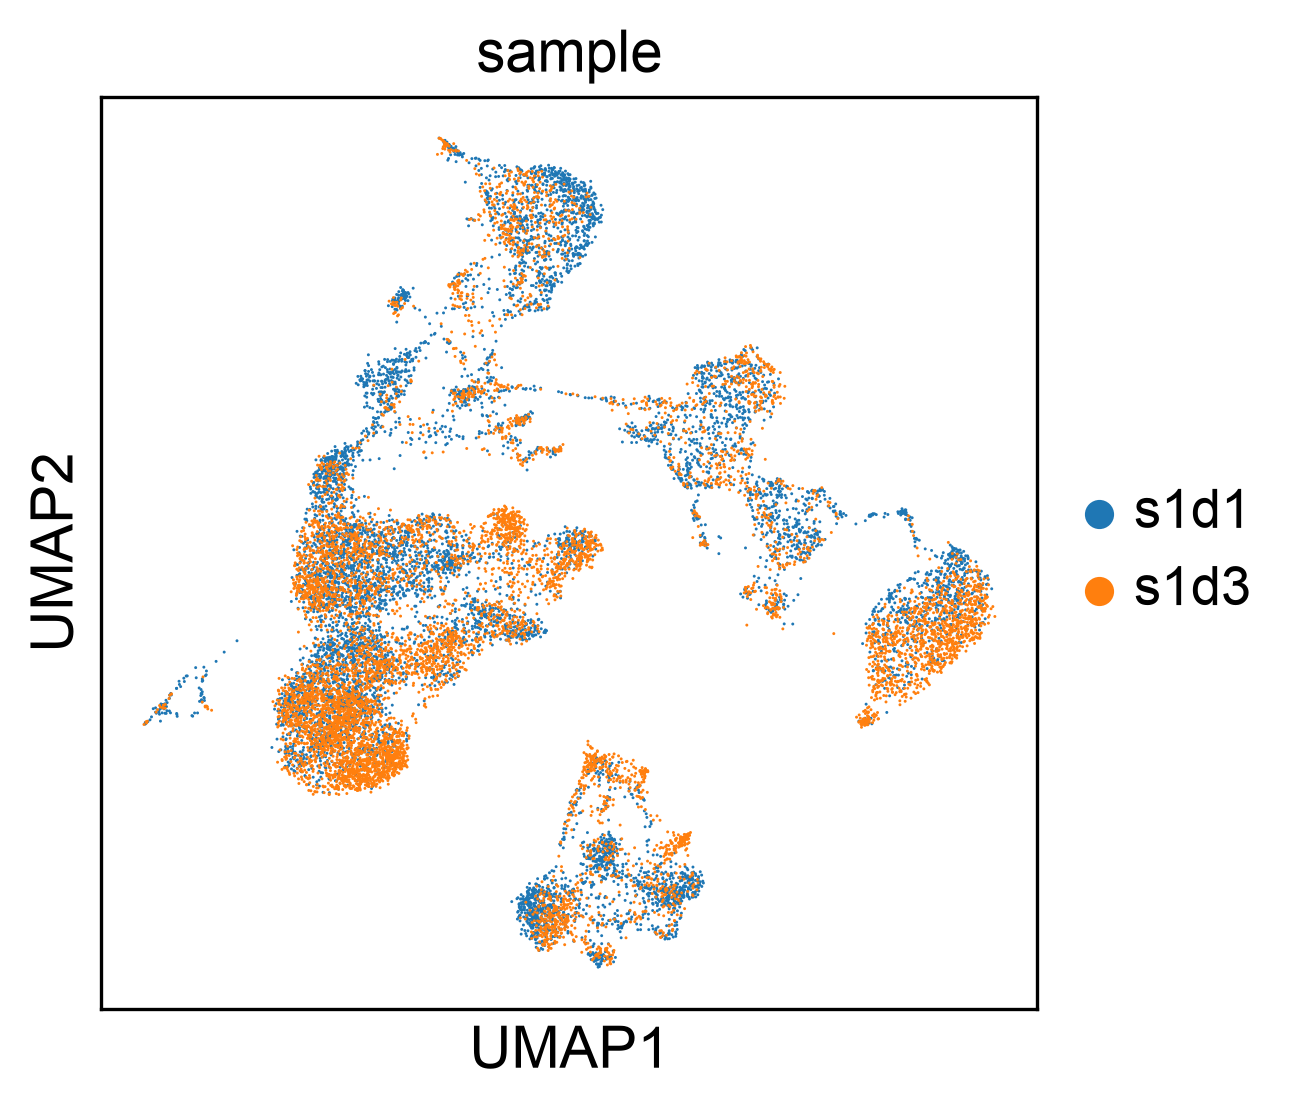

In [74]:
# Create umap 
sc.tl.umap(adata)

sc.pl.umap(adata,
           color = "sample",
           # setting a smaller point size to get better overlap
           size = 2
          )

In [76]:
# Using the igraph implementation and a fixed number of iterations can be significiantly faster, 
# espeically for larger datasets 

sc.tl.leiden(adata, flavor = "igraph", n_iterations = 2)

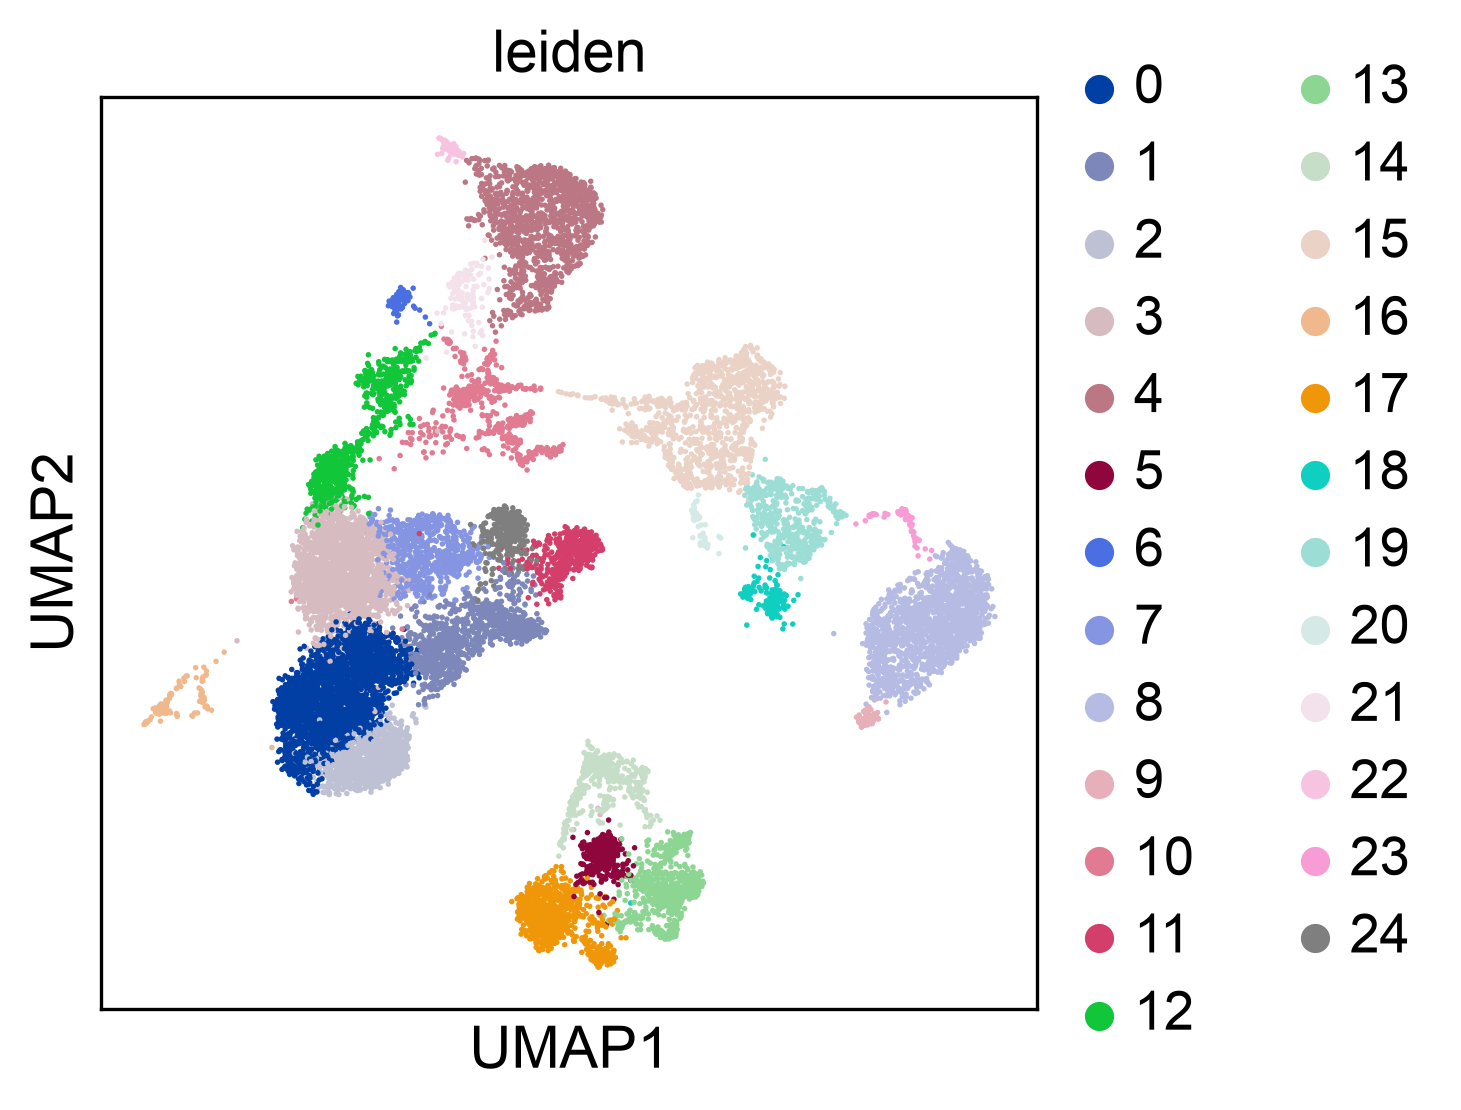

In [77]:
# Plot the Leiden umap 
sc.pl.umap(adata, color = ["leiden"])

In [78]:
# Extract cell communities from nearest graphs
for res in [0.02, 0.5, 2.0]:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

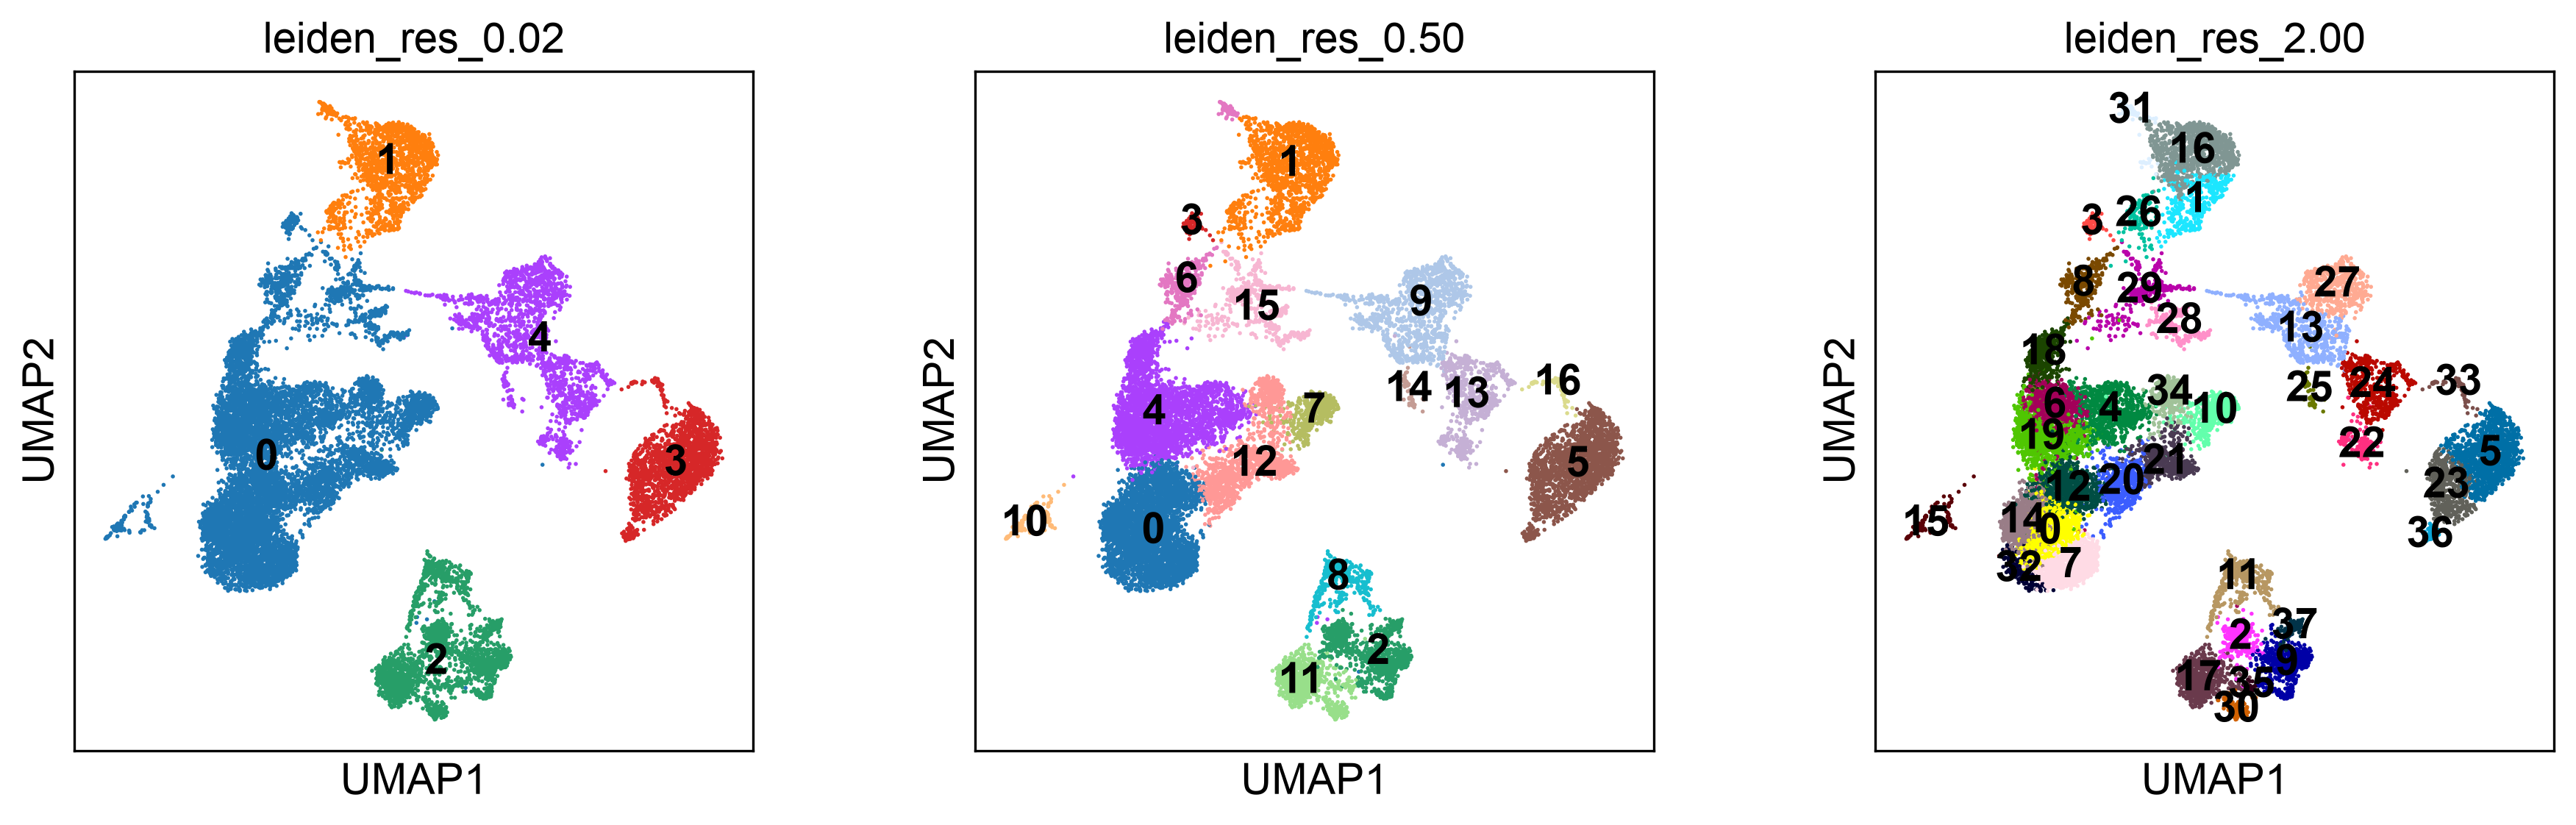

In [81]:
sc.pl.umap(
    adata,
    color=["leiden_res_0.02", "leiden_res_0.50", "leiden_res_2.00"],
    legend_loc = "on data",
)

In [82]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["GNLY", "NKG7", "CD247", "FCER1G", "TYROBP", "KLRG1", "FCGR3A"],
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "MS4A1",
        "ITGB1",
        "COL4A4",
        "PRDM1",
        "IRF4",
        "PAX5",
        "BCL11A",
        "BLK",
        "IGHD",
        "IGHM",
    ],
    "Plasma cells": ["MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", "JCHAIN"],
    # Note PAX5 is a negative marker
    "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
}

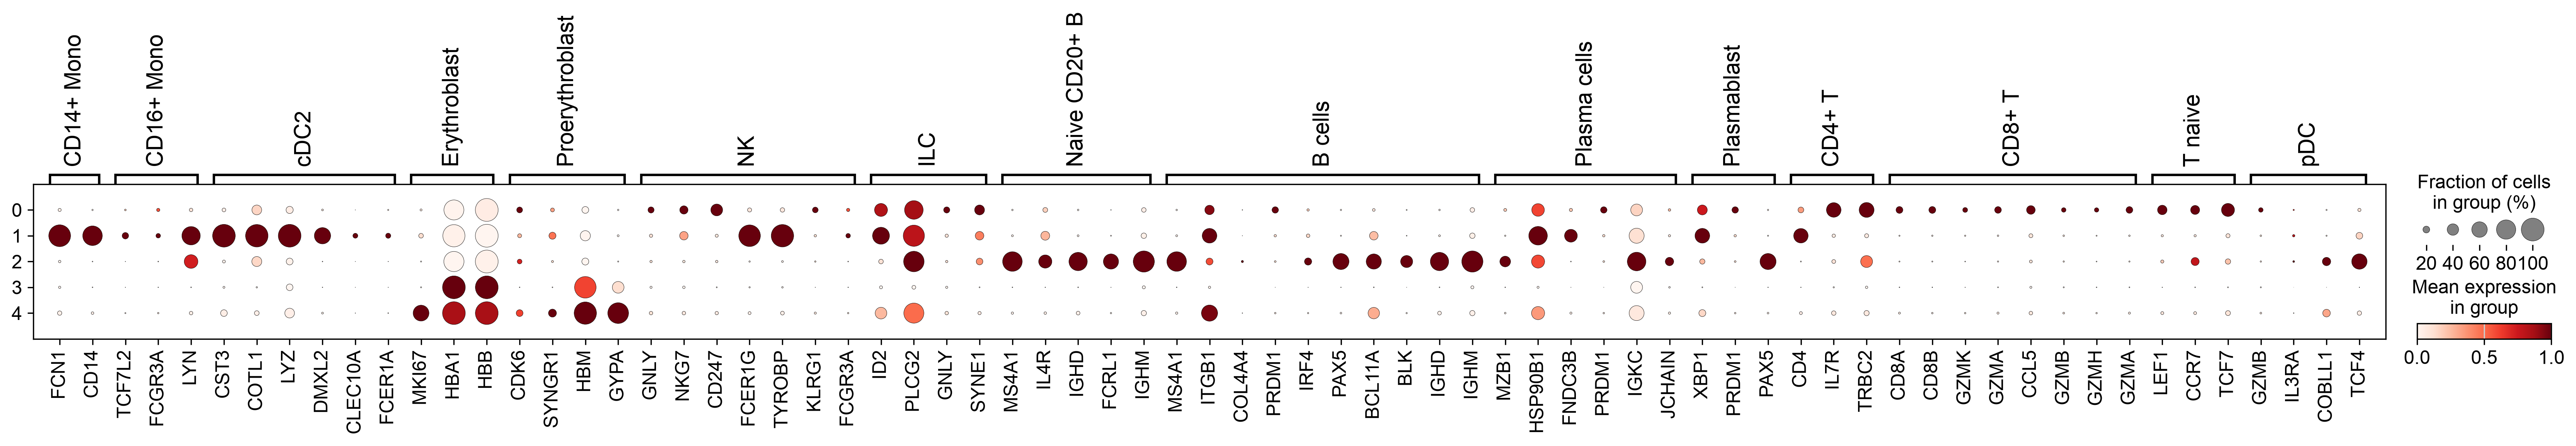

In [83]:
sc.pl.dotplot(adata, marker_genes, groupby = "leiden_res_0.02", standard_scale = "var")